# Notebook 04: Modelado de LSTM
*Rodrigo Ajmac Aroche - 22279*

*June Herrera - 21749* 

*Andres Mazariegos - 231038*

## 0. CONFIGURACIÓN

**Librerías**

In [1]:
import numpy as np
import pandas as pd
import itertools
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

In [2]:
# Librerías adicionales para predicción, comparación y catch22
import json
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from aeon.transformations.collection.feature_based import Catch22
from aeon.transformations.collection.feature_based._catch22 import (
    feature_names as C22_NOMBRES, feature_names_short as C22_CORTOS)

# El enunciado pide que la investigación sea reproducible: se fija la semilla de todo
# lo que es aleatorio (inicialización de pesos de la LSTM, K-means, barajado de lotes).
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

FIG = Path('figuras'); FIG.mkdir(exist_ok=True)
RES = Path('resultados'); RES.mkdir(exist_ok=True)

pd.set_option('display.width', 170)
pd.set_option('display.max_columns', 60)
plt.rcParams.update({
    'figure.dpi': 110, 'savefig.dpi': 150, 'savefig.bbox': 'tight',
    'font.size': 9, 'axes.grid': True, 'grid.alpha': .25,
    'axes.spines.top': False, 'axes.spines.right': False,
})
AZUL, NARANJA, VERDE, ROJO, GRIS, MORADO = '#1f4e79', '#e07b39', '#2e8b57', '#c0392b', '#7f8c8d', '#8e44ad'

def guardar(nombre):
    plt.savefig(FIG / f'{nombre}.png')

def miles(ax):
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, p: f'{v/1000:,.0f}'))

def metricas(real, pred):
    """Mismas métricas que el laboratorio 1, para que las cifras sean comparables."""
    real, pred = np.asarray(real, float), np.asarray(pred, float)
    mae = mean_absolute_error(real, pred)
    rmse = float(np.sqrt(mean_squared_error(real, pred)))
    m = real > 0                      # el MAPE se calcula solo sobre los meses no nulos
    mape = float(np.mean(np.abs((real[m] - pred[m]) / real[m])) * 100) if m.any() else np.nan
    return mae, rmse, mape

# Todo lo que se necesita para el informe se acumula aquí y se guarda al final.
R4 = {}

**Funciones**

In [3]:
def serie_de(mascara):
    return (base[mascara].groupby('fecha')['Viajero'].sum()
            .reindex(IDX).fillna(0).astype(float))

def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:(i + lookback), 0])
        y.append(data[i + lookback, 0])
    return np.array(X), np.array(y)

class TimeSeriesLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_layer_size=50, num_layers=1, dropout_rate=0.2):
        super().__init__()
        dropout = dropout_rate if num_layers > 1 else 0.0
        self.lstm = nn.LSTM(
            input_size=input_size, 
            hidden_size=hidden_layer_size, 
            num_layers=num_layers, 
            batch_first=True, 
            dropout=dropout
        )
        self.linear = nn.Linear(hidden_layer_size, 1)

    def forward(self, input_seq):
        lstm_out, _ = self.lstm(input_seq)
        predictions = self.linear(lstm_out[:, -1, :])
        return predictions

def optimizar_serie_pytorch(nombre, serie, corte, lookback, grid):
    print(f"{'='*60}\nOptimizando modelos (PyTorch) para: {nombre}\n{'='*60}")
    
    train_data = serie.iloc[:corte].values.reshape(-1, 1)
    test_data = serie.iloc[corte:].values.reshape(-1, 1)
    
    scaler = MinMaxScaler(feature_range=(0, 1))
    train_scaled = scaler.fit_transform(train_data)
    test_scaled = scaler.transform(test_data)
    
    X_train, y_train = create_sequences(train_scaled, lookback)
    X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
    
    combined_test = np.vstack((train_scaled[-lookback:], test_scaled))
    X_test, y_test = create_sequences(combined_test, lookback)
    X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
    
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    
    mejores = []
    
    for i, p in enumerate(grid):
        model = TimeSeriesLSTM(
            input_size=1, 
            hidden_layer_size=p['units'], 
            num_layers=p['lstm_layers']
        )
        loss_function = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
        dataset = TensorDataset(X_train_tensor, y_train_tensor)
        loader = DataLoader(dataset, batch_size=p['batch_size'], shuffle=False)
        
        model.train()
        for epoch in range(p['epochs']):
            for batch_X, batch_y in loader:
                optimizer.zero_grad()
                y_pred = model(batch_X)
                loss = loss_function(y_pred, batch_y)
                loss.backward()
                optimizer.step()
        
        model.eval()
        with torch.no_grad():
            preds_scaled = model(X_test_tensor).numpy()
            
        preds = scaler.inverse_transform(preds_scaled).flatten()
        preds = np.clip(preds, 0, None)
        real = serie.iloc[corte:].values
        
        rmse = np.sqrt(mean_squared_error(real, preds))
        mae = mean_absolute_error(real, preds)
        mejores.append({'Config': p, 'RMSE': rmse, 'MAE': mae, 'Modelo': model, 'Preds': preds})
    
    top_2 = sorted(mejores, key=lambda x: x['RMSE'])[:2]
    print(f"  TOP 1 -> RMSE: {top_2[0]['RMSE']:,.0f} | MAE: {top_2[0]['MAE']:,.0f}")
    print(f"           (Capas: {top_2[0]['Config']['lstm_layers']}, Unidades: {top_2[0]['Config']['units']}, Épocas: {top_2[0]['Config']['epochs']}, Lote: {top_2[0]['Config']['batch_size']})")
    
    print(f"  TOP 2 -> RMSE: {top_2[1]['RMSE']:,.0f} | MAE: {top_2[1]['MAE']:,.0f}")
    print(f"           (Capas: {top_2[1]['Config']['lstm_layers']}, Unidades: {top_2[1]['Config']['units']}, Épocas: {top_2[1]['Config']['epochs']}, Lote: {top_2[1]['Config']['batch_size']})\n")
    
    return top_2

In [4]:
RUTA = '../Datos_Crudos/Base_Migracion_2009-2026jun.xlsx'

## 1. PREPROCESAMIENTO

In [5]:
# ==========================================
# 1. CARGA Y CONSTRUCCIÓN DE LAS SERIES
# ==========================================
df = pd.read_excel(RUTA, sheet_name=0)
df['Viajero'] = df['Viajero'].astype(int)
df['fecha'] = pd.to_datetime(
    df['Año'].astype(str) + '-' + df['Mes cod'].astype(str).str.zfill(2) + '-01')

base = df
IDX = pd.date_range('2009-01-01', '2026-06-01', freq='MS')

In [6]:
rank_pais = base.groupby('País')['Viajero'].sum().sort_values(ascending=False)
top3_pais = list(rank_pais.head(3).index)
VIAS = ['Aérea', 'Terrestre', 'Marítima']

TODO = pd.Series(True, index=base.index)
MASCARAS = {'Total de viajeros': TODO}
for p in top3_pais:
    MASCARAS[f'País: {p}'] = base['País'] == p
for v in VIAS:
    MASCARAS[f'Vía: {v}'] = base['Vía'] == v

SERIES = {n: serie_de(m) for n, m in MASCARAS.items()}
print(f"Se construyeron {len(SERIES)} series correctamente.\n")

Se construyeron 7 series correctamente.



## 2. FINETUNING

In [7]:
N = len(IDX)
CORTE = int(N * 0.70)
LOOKBACK = 12
resultados_lstm = {}

param_grid = {
    'lstm_layers': [1, 2],
    'units': [32, 64],
    'epochs': [50, 100],
    'batch_size': [8, 16]
}
keys, values = zip(*param_grid.items())
grid_combinaciones = [dict(zip(keys, v)) for v in itertools.product(*values)]

In [8]:
# ==========================================
# 4. EJECUCIÓN DEL MODELADO SOBRE TODAS LAS SERIES
# ==========================================
for nombre_serie, serie_datos in SERIES.items():
    resultados_lstm[nombre_serie] = optimizar_serie_pytorch(
        nombre=nombre_serie, 
        serie=serie_datos, 
        corte=CORTE, 
        lookback=LOOKBACK, 
        grid=grid_combinaciones
    )

print("Proceso de modelado finalizado exitosamente.")

Optimizando modelos (PyTorch) para: Total de viajeros


  TOP 1 -> RMSE: 54,528 | MAE: 42,018
           (Capas: 1, Unidades: 32, Épocas: 100, Lote: 8)
  TOP 2 -> RMSE: 57,604 | MAE: 43,996
           (Capas: 1, Unidades: 64, Épocas: 50, Lote: 8)

Optimizando modelos (PyTorch) para: País: El Salvador


  TOP 1 -> RMSE: 27,581 | MAE: 20,516
           (Capas: 1, Unidades: 32, Épocas: 50, Lote: 8)
  TOP 2 -> RMSE: 28,130 | MAE: 20,093
           (Capas: 1, Unidades: 32, Épocas: 100, Lote: 8)

Optimizando modelos (PyTorch) para: País: Guatemala


  TOP 1 -> RMSE: 27,571 | MAE: 11,108
           (Capas: 1, Unidades: 32, Épocas: 100, Lote: 8)
  TOP 2 -> RMSE: 28,260 | MAE: 11,503
           (Capas: 2, Unidades: 64, Épocas: 50, Lote: 8)

Optimizando modelos (PyTorch) para: País: Estados Unidos de América


  TOP 1 -> RMSE: 9,879 | MAE: 7,666
           (Capas: 2, Unidades: 64, Épocas: 100, Lote: 8)
  TOP 2 -> RMSE: 10,612 | MAE: 8,161
           (Capas: 1, Unidades: 64, Épocas: 100, Lote: 8)

Optimizando modelos (PyTorch) para: Vía: Aérea


  TOP 1 -> RMSE: 17,710 | MAE: 13,335
           (Capas: 1, Unidades: 64, Épocas: 100, Lote: 8)
  TOP 2 -> RMSE: 18,316 | MAE: 13,402
           (Capas: 2, Unidades: 64, Épocas: 100, Lote: 8)

Optimizando modelos (PyTorch) para: Vía: Terrestre


  TOP 1 -> RMSE: 41,913 | MAE: 33,122
           (Capas: 1, Unidades: 32, Épocas: 100, Lote: 8)
  TOP 2 -> RMSE: 42,976 | MAE: 33,823
           (Capas: 1, Unidades: 64, Épocas: 100, Lote: 8)

Optimizando modelos (PyTorch) para: Vía: Marítima


  TOP 1 -> RMSE: 1,571 | MAE: 831
           (Capas: 1, Unidades: 32, Épocas: 100, Lote: 16)
  TOP 2 -> RMSE: 1,631 | MAE: 919
           (Capas: 1, Unidades: 64, Épocas: 100, Lote: 16)

Proceso de modelado finalizado exitosamente.


## 3. PREDICCIÓN CON EL MEJOR MODELO (punto 1.3)

De la rejilla de 16 configuraciones por serie se conservaron las dos mejores por RMSE.
Aquí se documentan sus métricas sobre el conjunto de prueba (**abril 2021 – junio 2026**,
63 meses, el mismo 30 % final que se usó en el laboratorio 1) y se predice con la mejor.

Las métricas son las tres del laboratorio anterior —MAE, RMSE y MAPE— calculadas con la
misma función, porque comparar modelos exige que el error se mida igual en ambos cuadernos.
El MAPE se calcula solo sobre los meses con valor observado distinto de cero (las series de
Guatemala y El Salvador tienen meses en cero por el cierre de fronteras de 2020).

In [9]:
# Clave corta de cada serie para nombrar figuras (misma convención del cuaderno 03)
CLAVES = {n: n.replace('Total de viajeros', 'total')
             .replace('País: ', 'pais_').replace('Vía: ', 'via_')
             .replace('Estados Unidos de América', 'usa')
             .replace(' ', '_').replace('á', 'a').replace('é', 'e').replace('í', 'i')
             .replace('ó', 'o').replace('ú', 'u').lower() for n in SERIES}

def etiqueta(cfg):
    return (f"{cfg['lstm_layers']} capa(s) · {cfg['units']} unid. · "
            f"{cfg['epochs']} épocas · lote {cfg['batch_size']}")

filas = []
for nombre, top in resultados_lstm.items():
    real = SERIES[nombre].iloc[CORTE:].values
    for puesto, r in enumerate(top, 1):
        mae, rmse, mape = metricas(real, r['Preds'])
        filas.append({'Serie': nombre, 'Modelo': f'LSTM-{puesto}',
                      'Configuración': etiqueta(r['Config']),
                      'MAE': round(mae), 'RMSE': round(rmse), 'MAPE %': round(mape, 1)})

tabla_lstm = pd.DataFrame(filas)
print('Las dos mejores configuraciones de cada serie (conjunto de prueba, 63 meses)\n')
print(tabla_lstm.to_string(index=False))
R4['top2_por_serie'] = tabla_lstm.to_dict('records')

Las dos mejores configuraciones de cada serie (conjunto de prueba, 63 meses)

                          Serie Modelo                               Configuración   MAE  RMSE  MAPE %
              Total de viajeros LSTM-1  1 capa(s) · 32 unid. · 100 épocas · lote 8 42018 54528    16.1
              Total de viajeros LSTM-2   1 capa(s) · 64 unid. · 50 épocas · lote 8 43996 57604    17.3
              País: El Salvador LSTM-1   1 capa(s) · 32 unid. · 50 épocas · lote 8 20516 27581    23.9
              País: El Salvador LSTM-2  1 capa(s) · 32 unid. · 100 épocas · lote 8 20093 28130    18.3
                País: Guatemala LSTM-1  1 capa(s) · 32 unid. · 100 épocas · lote 8 11108 27571    17.0
                País: Guatemala LSTM-2   2 capa(s) · 64 unid. · 50 épocas · lote 8 11503 28260    18.4
País: Estados Unidos de América LSTM-1  2 capa(s) · 64 unid. · 100 épocas · lote 8  7666  9879    17.5
País: Estados Unidos de América LSTM-2  1 capa(s) · 64 unid. · 100 épocas · lote 8  8161 10612    

In [10]:
# Diferencia entre la mejor y la segunda configuración de cada serie
brecha = (tabla_lstm.pivot(index='Serie', columns='Modelo', values='RMSE')
          .reindex(list(SERIES)))
brecha['Δ RMSE %'] = ((brecha['LSTM-2'] - brecha['LSTM-1']) / brecha['LSTM-1'] * 100).round(1)
print(brecha.to_string())
print(f"\nBrecha media entre la 1ra y la 2da configuración: {brecha['Δ RMSE %'].mean():.1f} %")

conf_top1 = pd.Series({n: etiqueta(t[0]['Config']) for n, t in resultados_lstm.items()})
print('\nConfiguración ganadora por serie:')
print(conf_top1.to_string())
R4['brecha_top1_top2'] = brecha.round(1).reset_index().to_dict('records')

Modelo                           LSTM-1  LSTM-2  Δ RMSE %
Serie                                                    
Total de viajeros                 54528   57604       5.6
País: El Salvador                 27581   28130       2.0
País: Guatemala                   27571   28260       2.5
País: Estados Unidos de América    9879   10612       7.4
Vía: Aérea                        17710   18316       3.4
Vía: Terrestre                    41913   42976       2.5
Vía: Marítima                      1571    1631       3.8

Brecha media entre la 1ra y la 2da configuración: 3.9 %

Configuración ganadora por serie:
Total de viajeros                   1 capa(s) · 32 unid. · 100 épocas · lote 8
País: El Salvador                    1 capa(s) · 32 unid. · 50 épocas · lote 8
País: Guatemala                     1 capa(s) · 32 unid. · 100 épocas · lote 8
País: Estados Unidos de América     2 capa(s) · 64 unid. · 100 épocas · lote 8
Vía: Aérea                          1 capa(s) · 64 unid. · 100 épocas 

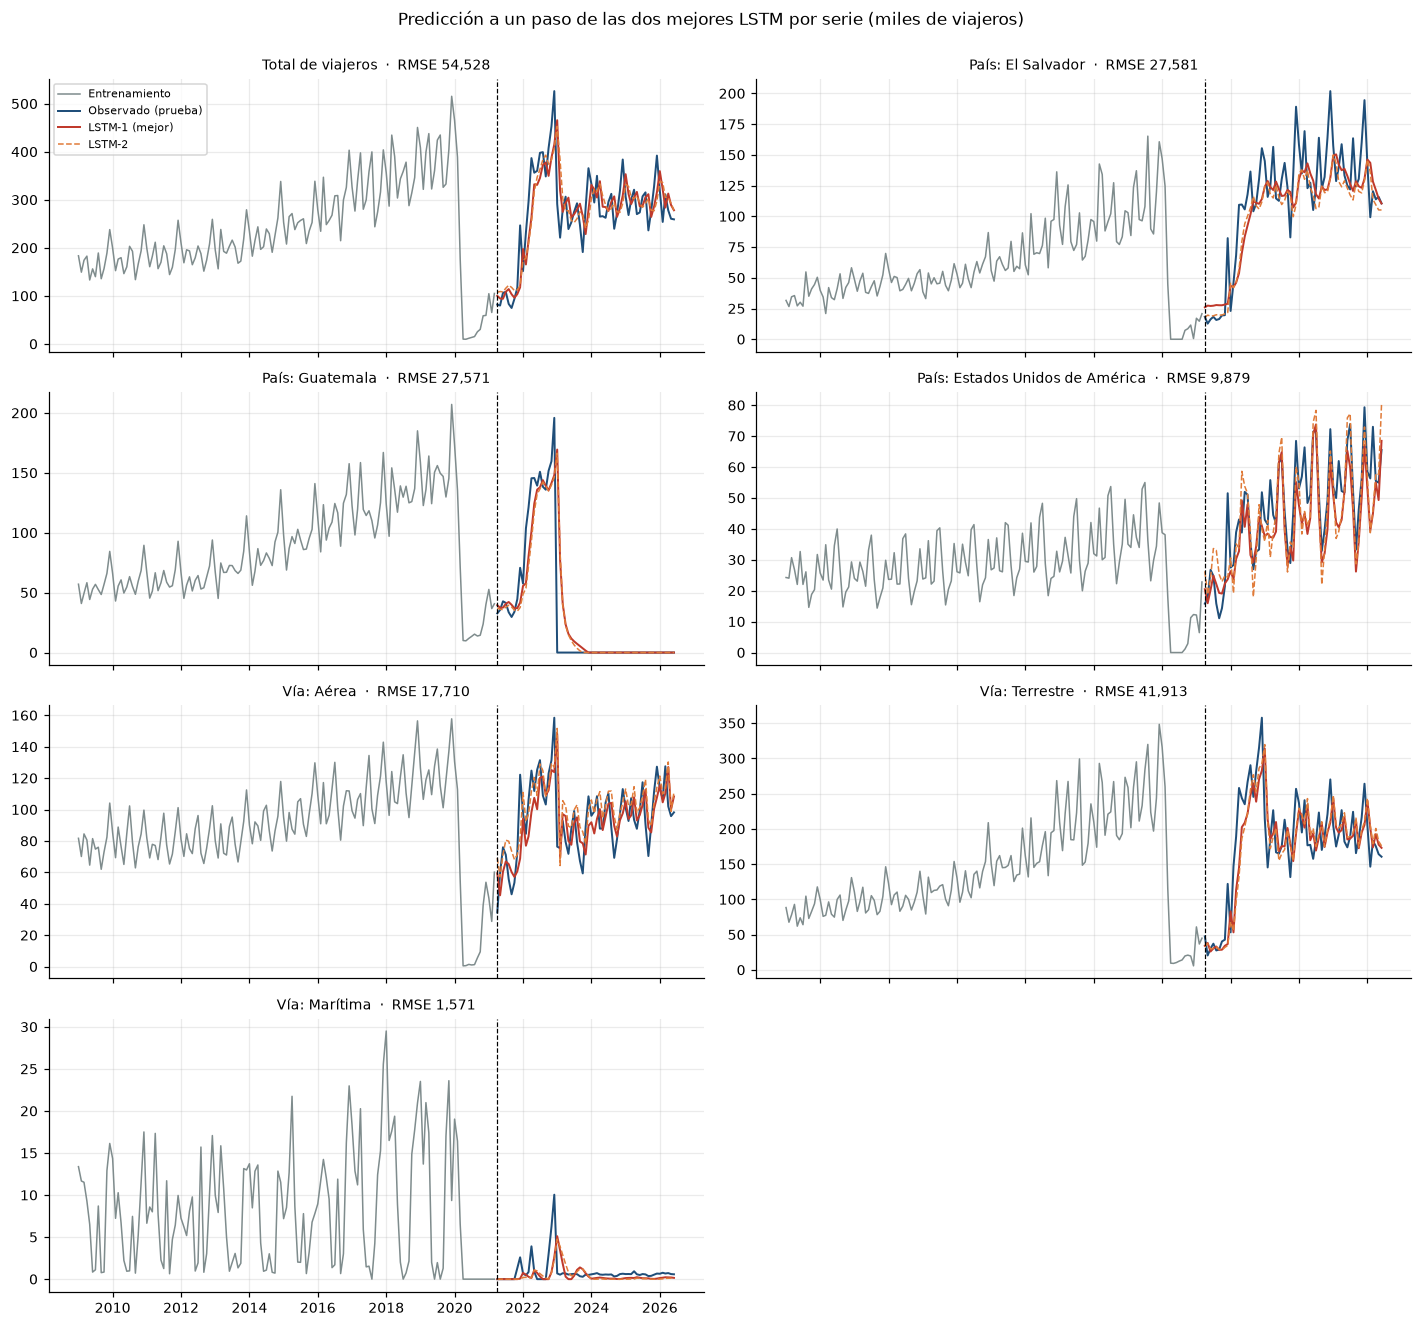

In [11]:
# Predicción de la mejor configuración de cada serie sobre el período de prueba
fig, axes = plt.subplots(4, 2, figsize=(13, 12), sharex=True)
for ax, (nombre, top) in zip(axes.ravel(), resultados_lstm.items()):
    s = SERIES[nombre]
    ax.plot(s.index[:CORTE], s.values[:CORTE], lw=1, color=GRIS, label='Entrenamiento')
    ax.plot(s.index[CORTE:], s.values[CORTE:], lw=1.3, color=AZUL, label='Observado (prueba)')
    ax.plot(s.index[CORTE:], top[0]['Preds'], lw=1.3, color=ROJO, label='LSTM-1 (mejor)')
    ax.plot(s.index[CORTE:], top[1]['Preds'], lw=1, ls='--', color=NARANJA, label='LSTM-2')
    ax.axvline(IDX[CORTE], ls='--', c='k', lw=.8)
    ax.set_title(f"{nombre}  ·  RMSE {top[0]['RMSE']:,.0f}", fontsize=9)
    miles(ax)
axes.ravel()[0].legend(fontsize=7)
axes.ravel()[-1].axis('off')
fig.suptitle('Predicción a un paso de las dos mejores LSTM por serie (miles de viajeros)', y=1.0)
plt.tight_layout(); guardar('40_lstm_pred_todas'); plt.show()

### 3.1 Lectura de los resultados del tuneo (puntos 1.2 y 1.3)

**Qué se tuneó.** La rejilla cruzó 4 hiperparámetros —capas LSTM (1, 2), unidades ocultas (32, 64),
épocas (50, 100) y tamaño de lote (8, 16)— dando **16 configuraciones por serie y 112 modelos
entrenados** en total. De cada serie se conservaron las dos mejores por RMSE, que son los "al menos
dos modelos con configuraciones diferentes" que pide el enunciado.

**Qué configuración gana.** El patrón es muy consistente: **una sola capa LSTM** gana en 6 de las 7
series (la excepción es Estados Unidos, con 2 capas y 64 unidades), **32 unidades** bastan en 5 de 7,
y **100 épocas** con **lote 8** es la combinación dominante. Con 135 ventanas de entrenamiento, las
redes más grandes no tienen datos para justificar su capacidad: la segunda capa y las 64 unidades
solo ayudan donde la serie es más estacional y regular (Estados Unidos, con la mayor fuerza
estacional del laboratorio 1, F = 0.929). Los lotes pequeños ayudan porque multiplican el número de
actualizaciones del gradiente en un conjunto tan corto.

**Qué tan sensible es el modelo a la configuración.** La brecha de RMSE entre la mejor y la segunda
configuración es de solo **2.0 % a 7.4 % (3.9 % en promedio)**. Es decir: el hiperparámetro no es lo
que decide la calidad del pronóstico; lo que decide es la serie. La diferencia entre predecir
*Vía: Aérea* (MAPE 15.3 %) y *Vía: Marítima* (MAPE 105.7 %) es de un orden de magnitud, mientras que
cambiar de arquitectura mueve el error unos pocos puntos porcentuales.

**Qué serie se predice mejor.** Con el MAPE, que es lo comparable entre escalas: *Vía: Aérea*
(15.3 %), *Total de viajeros* (16.1 %) y *País: Guatemala* (17.0 %) son las mejor predichas.
*Vía: Marítima* es la peor con diferencia (MAPE 105.7 %), pero su MAE es de solo 831 viajeros: el
MAPE se dispara porque la serie cae a valores cercanos a cero tras 2020 y cualquier error absoluto
pequeño es enorme en términos relativos. Es un caso donde el MAPE deja de ser informativo y hay que
leer el MAE.